# Parkinson's disease demonstrations

This notebook demonstrates four tabular classifiers on one fixed Parkinson's train/test split: KNN, a decision tree, a random forest, and a neural network. It is deliberately small and reproducible: each model sees the same training data, is evaluated on the same untouched test data, and produces a simple plot that makes its behavior easier to study.

The goal is not to find a production-ready medical model. The goal is to connect an algorithm's inductive bias—the assumptions it uses to generalize—to a visible parameter sweep or learning curve.

In [1]:
# Keep paths relative to the repository so the notebook can be run from its root.
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# StandardScaler is used only for models whose calculations depend on feature scale.
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == 'demonstrations' else Path.cwd()
sys.path.insert(0, str(ROOT))

from algorithms.decision_tree import decision_tree_classifier
from algorithms.knn_implementation import KNN_classifier
from algorithms.neural_network import NeuralNetwork
from algorithms.random_forest import random_forest_classifier

DATA_DIR = ROOT / 'data'
RESULTS_DIR = ROOT / 'results' / 'parkinsons'
FIGURES_DIR = ROOT / 'figures' / 'parkinsons'
SEED = 123

for path in (RESULTS_DIR, FIGURES_DIR):
    path.mkdir(parents=True, exist_ok=True)

# The split is fixed in data/ so every algorithm is compared on identical examples.
train = pd.read_csv(DATA_DIR / 'parkinsons_train.csv')
test = pd.read_csv(DATA_DIR / 'parkinsons_test.csv')
feature_names = list(train.columns[:-1])
attribute_types = ['numeric'] * len(feature_names)
# The final column is the binary target; all preceding columns are numeric features.
X_train = train.iloc[:, :-1].to_numpy(float)
y_train = train.iloc[:, -1].to_numpy(bool)
X_test = test.iloc[:, :-1].to_numpy(float)
y_test = test.iloc[:, -1].to_numpy(bool)
print(f'train={X_train.shape}, test={X_test.shape}')

train=(156, 22), test=(39, 22)


In [2]:
# Use the same accuracy and F1 definitions for every classifier.
def metrics(labels, predictions):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    tp = np.sum((labels == 1) & (predictions == 1))
    fp = np.sum((labels == 0) & (predictions == 1))
    fn = np.sum((labels == 1) & (predictions == 0))
    accuracy = np.mean(labels == predictions)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return float(accuracy), float(f1)

# A shared plotting helper keeps the three parameter sweeps comparable.
def plot_parameter_curve(performance, parameter, output_path):
    figure, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
    for axis, metric, label in zip(axes, ('accuracy', 'f1'), ('Accuracy', 'F1')):
        axis.plot(performance[parameter], performance[f'{metric}_test'], marker='o')
        axis.set_xlabel(parameter)
        axis.set_ylabel(label)
        axis.grid(True)
    figure.tight_layout()
    figure.savefig(output_path, bbox_inches='tight')
    plt.show()


## K-nearest neighbors

KNN does not learn a compact set of parameters. Instead, it classifies a test point from the labels of nearby training points. Its inductive bias is local smoothness: nearby observations are expected to have similar labels.

The features are standardized because KNN uses Euclidean distance. Without scaling, a feature with a larger numeric range could dominate the distance. The six-point curve shows how test accuracy and F1 change as `k` increases. Small `k` values preserve local detail; larger values average over a wider neighborhood and can smooth away useful structure.

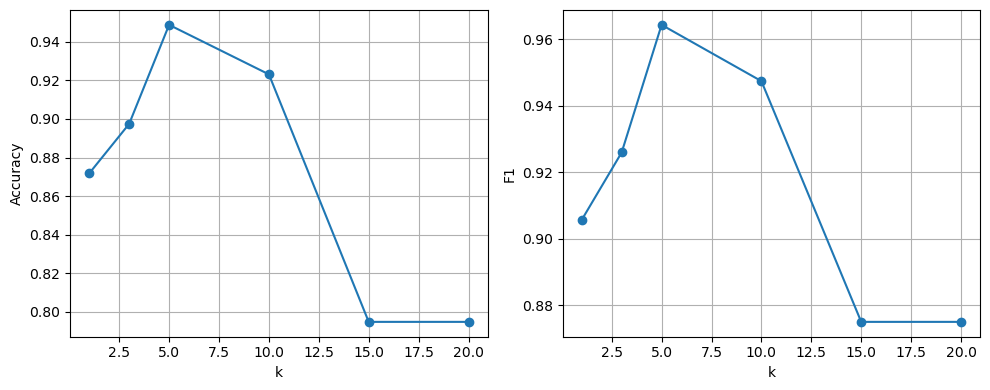

,k,accuracy_test,f1_test
0,1,0.871795,0.905660
1,3,0.897436,0.925926
2,5,0.948718,0.964286
3,10,0.923077,0.947368
4,15,0.794872,0.875000
5,20,0.794872,0.875000


In [3]:
# Fit scaling on training data only, then apply the same transformation to the test data.
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Each k gives a different neighborhood size and therefore a different bias toward smoothing.
knn_rows = []
for k in (1, 3, 5, 10, 15, 20):
    model = KNN_classifier(k).fit(X_train_scaled, y_train)
    accuracy, f1 = metrics(y_test, model.predict(X_test_scaled))
    knn_rows.append({'k': k, 'accuracy_test': accuracy, 'f1_test': f1})
knn_performance = pd.DataFrame(knn_rows)
(RESULTS_DIR / 'KNN').mkdir(exist_ok=True)
(FIGURES_DIR / 'KNN').mkdir(exist_ok=True)
knn_performance.to_csv(RESULTS_DIR / 'KNN' / 'performance.csv', index=False)
plot_parameter_curve(knn_performance, 'k', FIGURES_DIR / 'KNN' / 'performance_plot.png')
knn_performance

## Decision tree

A decision tree predicts by asking a sequence of threshold questions, such as whether a feature is below a learned value. Its inductive bias is that useful class structure can be represented by axis-aligned partitions of the feature space.

The `maximum_depth` parameter makes the bias–variance trade-off directly visible. A shallow tree has fewer rules and may underfit; a deep tree can represent more detailed regions but may fit noise. The curve evaluates six depths while keeping the data split and tree settings fixed.

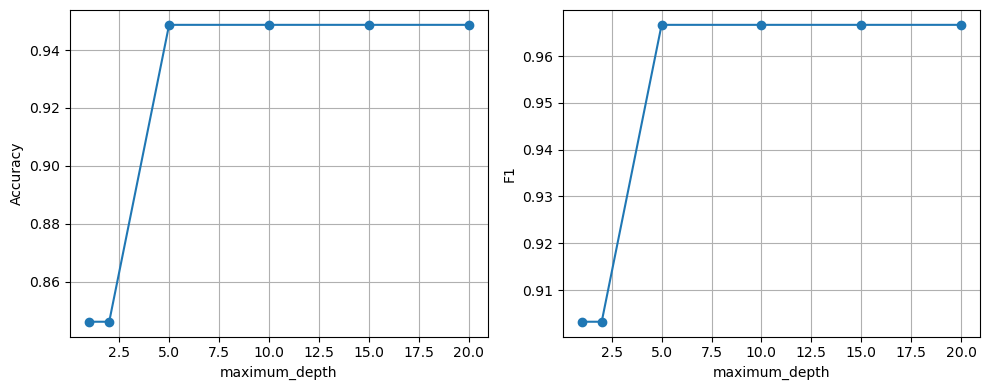

,maximum_depth,accuracy_test,f1_test
0,1,0.846154,0.903226
1,2,0.846154,0.903226
2,5,0.948718,0.966667
3,10,0.948718,0.966667
4,15,0.948718,0.966667
5,20,0.948718,0.966667


In [4]:
# Vary only maximum depth so the effect of tree complexity is easy to isolate.
tree_rows = []
for depth in (1, 2, 5, 10, 15, 20):
    model = decision_tree_classifier(
        split_criterion='information_gain',
        majority_class_threshold=1.0,
        minimum_size_for_split=10,
        minimum_split_quality_score=0.0,
        maximum_depth=depth,
        random_attribute_selection=False,
        random_seed=SEED,
    )
    model.fit(X_train, y_train, feature_names, attribute_types)
    accuracy, f1 = metrics(y_test, model.predict(X_test))
    tree_rows.append({'maximum_depth': depth, 'accuracy_test': accuracy, 'f1_test': f1})
tree_performance = pd.DataFrame(tree_rows)
(RESULTS_DIR / 'DecisionTree').mkdir(exist_ok=True)
(FIGURES_DIR / 'DecisionTree').mkdir(exist_ok=True)
tree_performance.to_csv(RESULTS_DIR / 'DecisionTree' / 'performance.csv', index=False)
plot_parameter_curve(tree_performance, 'maximum_depth', FIGURES_DIR / 'DecisionTree' / 'performance_plot.png')
tree_performance

## Random forest

A random forest averages many decision trees. Randomness in the training samples and selected features makes the trees different, while voting combines their predictions. Its inductive bias is still tree-like partitioning, but aggregation usually reduces the variance of one individual tree.

Here, `maximum_depth` is fixed and `ntree` is varied across six values. Increasing the number of trees can stabilize the estimate, although test performance need not improve monotonically on one small split. The sweep remains practical because the Parkinson's dataset is small.

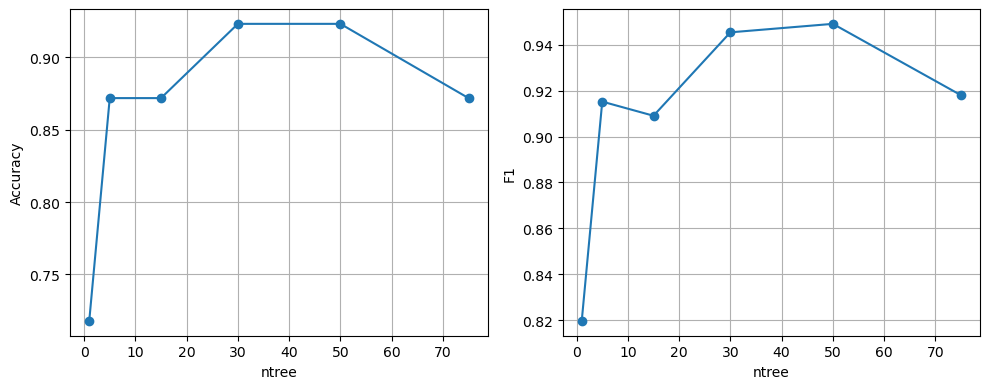

,ntree,accuracy_test,f1_test
0,1,0.717949,0.819672
1,5,0.871795,0.915254
2,15,0.871795,0.909091
3,30,0.923077,0.945455
4,50,0.923077,0.949153
5,75,0.871795,0.918033


In [5]:
# Keep tree depth fixed while increasing the number of independently randomized trees.
forest_rows = []
for tree_count in (1, 5, 15, 30, 50, 75):
    model = random_forest_classifier(
        ntree=tree_count,
        split_criterion='information_gain',
        majority_class_threshold=1.0,
        minimum_size_for_split=10,
        minimum_split_quality_score=0.0,
        maximum_depth=5,
        random_seed=SEED,
    )
    model.fit(X_train, y_train, feature_names, attribute_types)
    accuracy, f1 = metrics(y_test, model.predict(X_test))
    forest_rows.append({'ntree': tree_count, 'accuracy_test': accuracy, 'f1_test': f1})
forest_performance = pd.DataFrame(forest_rows)
(RESULTS_DIR / 'RandomForest').mkdir(exist_ok=True)
(FIGURES_DIR / 'RandomForest').mkdir(exist_ok=True)
forest_performance.to_csv(RESULTS_DIR / 'RandomForest' / 'performance.csv', index=False)
plot_parameter_curve(forest_performance, 'ntree', FIGURES_DIR / 'RandomForest' / 'performance_plot.png')
forest_performance

## Neural network

A feed-forward neural network learns a sequence of linear transformations and nonlinear activations. Its inductive bias is more flexible than the local neighborhoods of KNN or the explicit partitions of a tree: it can represent distributed feature interactions. That flexibility also makes optimization and regularization important.

The network uses standardized features, one hidden layer, and L2 regularization. The three panels compare training and test cost, accuracy, and F1 as training progresses. If training improves while test performance worsens, that is evidence of overfitting; if both improve together, the learned representation is generalizing better.

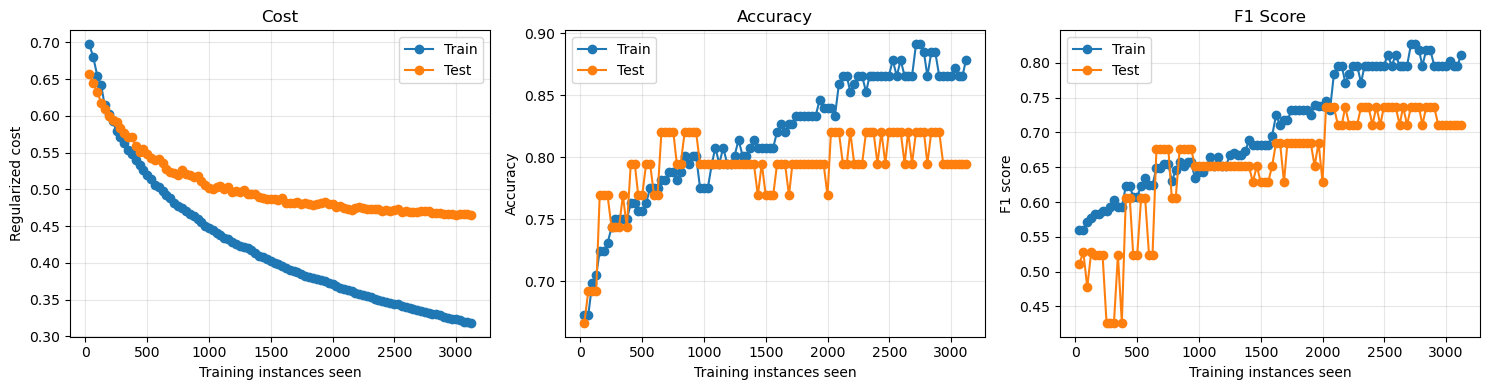

,iterations,batches,updates,train_instances_seen,train_cost,test_cost,train_accuracy,test_accuracy,train_f1,test_f1
99,20,5,100,3120,0.31857,0.465286,0.878205,0.794872,0.811054,0.711111


In [6]:
# A small one-hidden-layer network keeps the demonstration quick and interpretable.
network = NeuralNetwork(num_hidden_layers=1, num_neurons_per_hidden_layer=8)
network.configure_for_fit(regularization_strength=0.01, step_size=0.3)
# record_history lets us compare optimization on the training and test sets over time.
history = pd.DataFrame(network.fit(
    X_train_scaled, y_train, num_iterations=20, batch_size=32,
    random_seed=SEED, shuffle=True, verbose=False, record_history=True,
    X_test=X_test_scaled, y_test=y_test,
))
(RESULTS_DIR / 'NeuralNetwork').mkdir(exist_ok=True)
(FIGURES_DIR / 'NeuralNetwork').mkdir(exist_ok=True)
history.to_csv(RESULTS_DIR / 'NeuralNetwork' / 'history.csv', index=False)
figure, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, train_column, test_column, title, ylabel in zip(
        axes, ('train_cost', 'train_accuracy', 'train_f1'),
        ('test_cost', 'test_accuracy', 'test_f1'),
        ('Cost', 'Accuracy', 'F1 Score'),
        ('Regularized cost', 'Accuracy', 'F1 score')):
    axis.plot(history.train_instances_seen, history[train_column], marker='o', label='Train')
    axis.plot(history.train_instances_seen, history[test_column], marker='o', label='Test')
    axis.set_title(title)
    axis.set_xlabel('Training instances seen')
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.3)
    axis.legend()
figure.tight_layout()
figure.savefig(FIGURES_DIR / 'NeuralNetwork' / 'history_plot.png', bbox_inches='tight')
plt.show()
accuracy, f1 = metrics(y_test, network.predict_label(X_test_scaled))
pd.DataFrame([{'accuracy': accuracy, 'f1': f1}]).to_csv(RESULTS_DIR / 'NeuralNetwork' / 'test_metrics.csv', index=False)
history.tail(1)

## Interpretation

Use the plots to ask questions rather than to declare a universal winner. Which models are sensitive to their complexity parameter? Does increasing complexity improve both accuracy and F1? Do the training and test histories move together? These questions connect the observed behavior to each model's inductive bias.

Multinomial Naive Bayes is intentionally not applied here because its usual input is token/count data, such as word frequencies, rather than continuous biomedical measurements. A fuller summary of the algorithm assumptions is available in the [README](README.md#algorithms-and-inductive-bias).